# Actividad 2.2: Aprendizaje Supervisado
## Dataset: Breast Cancer (Ljubljana, Yugoslavia)

**Integrantes del equipo:**
*   Abigail Pérez García | A01736815
*   Alvaro Alberto Cruz Jiménez | A01737453
*   Fernando Maggi Llerandi | A01736935
*   Rodrigo López Guerra | A01737437

---

**Descripción del dataset:**
286 instancias, 9 atributos categóricos + 1 clase binaria (`no-recurrence-events` / `recurrence-events`).  
Distribución de clases: 201 (70.3%) vs 85 (29.7%) — clases desbalanceadas.  


## I. Selección de datos y Preprocesamiento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Cargar datos ──────────────────────────────────────────────────────────────
df = pd.read_csv('Cancer.csv')

print('Dimensiones del dataset:', df.shape)
print('\nPrimeras filas:')
df.head()

Dimensiones del dataset: (286, 10)

Primeras filas:


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,40-49,premeno,15-19,0-2,yes,3,right,left_up,no,recurrence-events
1,50-59,ge40,15-19,0-2,no,1,right,central,no,no-recurrence-events
2,50-59,ge40,35-39,0-2,no,2,left,left_low,no,recurrence-events
3,40-49,premeno,35-39,0-2,yes,3,right,left_low,yes,no-recurrence-events
4,40-49,premeno,30-34,3-5,yes,2,left,right_up,no,recurrence-events


In [ ]:
print('Tipos de datos originales:')
print(df.dtypes)
print('\nValores únicos por columna:')
for col in df.columns:
    print(f'  {col}: {sorted(df[col].dropna().unique().tolist())}')

Tipos de datos originales:
age            object
menopause      object
tumor-size     object
inv-nodes      object
node-caps      object
deg-malig       int64
breast         object
breast-quad    object
irradiat       object
Class          object
dtype: object

Valores únicos por columna:
  age: ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
  menopause: ['ge40', 'lt40', 'premeno']
  tumor-size: ['0-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54']
  inv-nodes: ['0-2', '12-14', '15-17', '24-26', '3-5', '6-8', '9-11']
  node-caps: ['?', 'no', 'yes']
  deg-malig: [1, 2, 3]
  breast: ['left', 'right']
  breast-quad: ['?', 'central', 'left_low', 'left_up', 'right_low', 'right_up']
  irradiat: ['no', 'yes']
  Class: ['no-recurrence-events', 'recurrence-events']


In [ ]:
print('Valores faltantes por columna:')
print(df.isnull().sum())
print(f'\nTotal de instancias con al menos un valor faltante: {df.isnull().any(axis=1).sum()}')

Valores faltantes por columna:
age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiat       0
Class          0
dtype: int64

Total de instancias con al menos un valor faltante: 0


### 1.1 Manejo de valores faltantes

Según el README, los atributos `node-caps` (8 faltantes) y `breast-quad` (1 faltante) tienen valores `?`.  
Se reemplazarán los `?` por `NaN` y luego se imputará con la **moda** de cada columna, ya que todos los atributos son categóricos.


In [ ]:
# Reemplazar '?' por NaN
df.replace('?', np.nan, inplace=True)

# Imputar con la moda
for col in df.columns:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f'  {col}: imputado con moda = "{moda}"')

print('\nValores faltantes tras imputación:', df.isnull().sum().sum())

  node-caps: imputado con moda = "no"
  breast-quad: imputado con moda = "left_low"

Valores faltantes tras imputación: 0


### 1.2 Transformación de atributos a numérico

Todos los atributos son categóricos. Se aplican distintas estrategias según su naturaleza:

| Atributo | Tipo | Justificación de codificación |
|---|---|---|
| `age` | **Ordinal** | Rangos etarios con orden natural → codificación ordinal |
| `menopause` | **Ordinal** | `lt40 < premeno < ge40` → codificación ordinal |
| `tumor-size` | **Ordinal** | Rangos de tamaño con orden natural → codificación ordinal |
| `inv-nodes` | **Ordinal** | Rangos de nodos invadidos con orden → codificación ordinal |
| `node-caps` | **Nominal binario** | `yes/no` → 1/0 |
| `deg-malig` | **Ordinal** | Ya es numérico (1, 2, 3), solo se convierte a int |
| `breast` | **Nominal binario** | `left/right` → 0/1 |
| `breast-quad` | **Nominal** | 5 categorías sin orden → One-Hot Encoding |
| `irradiat` | **Nominal binario** | `yes/no` → 1/0 |
| `Class` | **Target** | `no-recurrence-events` → 0, `recurrence-events` → 1 |


In [ ]:
df_enc = df.copy()

# ── Ordinales con orden natural ───────────────────────────────────────────────
age_order = ['10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90-99']
df_enc['age'] = pd.Categorical(df_enc['age'], categories=age_order, ordered=True).codes

menopause_order = ['lt40','premeno','ge40']
df_enc['menopause'] = pd.Categorical(df_enc['menopause'], categories=menopause_order, ordered=True).codes

tumor_order = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59']
df_enc['tumor-size'] = pd.Categorical(df_enc['tumor-size'], categories=tumor_order, ordered=True).codes

invnodes_order = ['0-2','3-5','6-8','9-11','12-14','15-17','18-20','21-23','24-26','27-29','30-32','33-35','36-39']
df_enc['inv-nodes'] = pd.Categorical(df_enc['inv-nodes'], categories=invnodes_order, ordered=True).codes

# ── Nominales binarios ────────────────────────────────────────────────────────
df_enc['node-caps'] = df_enc['node-caps'].map({'no': 0, 'yes': 1})
df_enc['breast']    = df_enc['breast'].map({'left': 0, 'right': 1})
df_enc['irradiat']  = df_enc['irradiat'].map({'no': 0, 'yes': 1})

# ── deg-malig ya es numérico ──────────────────────────────────────────────────
df_enc['deg-malig'] = df_enc['deg-malig'].astype(int)

# ── breast-quad: One-Hot Encoding (nominal sin orden) ────────────────────────
df_enc = pd.get_dummies(df_enc, columns=['breast-quad'], drop_first=False)

# ── Variable objetivo ─────────────────────────────────────────────────────────
df_enc['Class'] = df_enc['Class'].map({'no-recurrence-events': 0, 'recurrence-events': 1})

print('Dataset preprocesado:')
print(df_enc.dtypes)
print(f'\nForma final: {df_enc.shape}')
df_enc.head()

Dataset preprocesado:
age                       int8
menopause                 int8
tumor-size                int8
inv-nodes                 int8
node-caps                int64
deg-malig                int64
breast                   int64
irradiat                 int64
Class                    int64
breast-quad_central       bool
breast-quad_left_low      bool
breast-quad_left_up       bool
breast-quad_right_low     bool
breast-quad_right_up      bool
dtype: object

Forma final: (286, 14)


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,irradiat,Class,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up
0,3,1,3,0,1,3,1,0,1,False,False,True,False,False
1,4,2,3,0,0,1,1,0,0,True,False,False,False,False
2,4,2,7,0,0,2,0,0,1,False,True,False,False,False
3,3,1,7,0,1,3,1,1,0,False,True,False,False,False
4,3,1,6,1,1,2,0,0,1,False,False,False,False,True


### 1.3 Normalización de atributos ordinales

Los atributos ordinales (`age`, `menopause`, `tumor-size`, `inv-nodes`, `deg-malig`) tienen rangos distintos.  
Se aplica normalización **Min-Max** para llevarlos al rango [0, 1], lo que es especialmente importante para kNN (sensible a la escala de los datos).

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Columnas a normalizar (ordinales numéricas)
cols_normalizar = ['age', 'menopause', 'tumor-size', 'inv-nodes', 'deg-malig']

scaler = MinMaxScaler()
df_enc[cols_normalizar] = scaler.fit_transform(df_enc[cols_normalizar])

print('Estadísticas tras normalización:')
df_enc[cols_normalizar].describe().round(3)

Estadísticas tras normalización:


,age,menopause,tumor-size,inv-nodes,deg-malig
count,286.000,286.000,286.000,286.000,286.000
mean,0.533,0.713,0.488,0.066,0.524
std,0.202,0.271,0.211,0.144,0.369
min,0.000,0.000,0.000,0.000,0.000
25%,0.400,0.500,0.400,0.000,0.500
50%,0.600,0.500,0.500,0.000,0.500
75%,0.600,1.000,0.600,0.125,1.000
max,1.000,1.000,1.000,1.000,1.000


### 1.4 Separación de conjuntos (70% entrenamiento / 30% evaluación)

Se usa `stratify=y` para preservar la proporción de clases (70.3% / 29.7%) en ambos subconjuntos.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_enc.drop(columns=['Class'])
y = df_enc['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} instancias')
print(f'  Clase 0 (no-recurrence): {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')
print(f'  Clase 1 (recurrence):    {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'\nEvaluación: {X_test.shape[0]} instancias')
print(f'  Clase 0 (no-recurrence): {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')
print(f'  Clase 1 (recurrence):    {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')

Entrenamiento: 200 instancias
  Clase 0 (no-recurrence): 141 (70.5%)
  Clase 1 (recurrence):    59 (29.5%)

Evaluación: 86 instancias
  Clase 0 (no-recurrence): 60 (69.8%)
  Clase 1 (recurrence):    26 (30.2%)


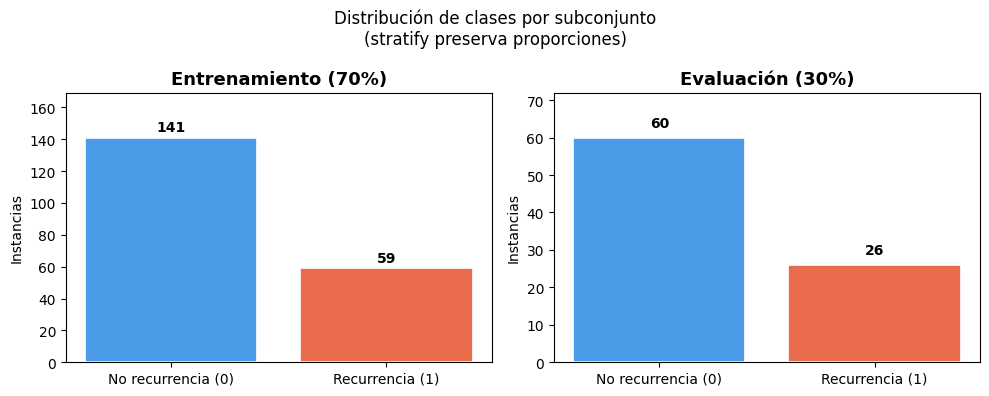

✓ La proporción ~70% / ~30% se conserva en ambos conjuntos gracias a stratify=y


In [ ]:
# Gráfica de distribución de clases en ambos conjuntos
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['No recurrencia (0)', 'Recurrencia (1)']
colores = ['#4C9BE8', '#E86B4C']

for ax, (counts, title) in zip(axes, [
    (y_train.value_counts().sort_index(), 'Entrenamiento (70%)'),
    (y_test.value_counts().sort_index(),  'Evaluación (30%)')
]):
    bars = ax.bar(labels, counts.values, color=colores, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Instancias')
    ax.set_ylim(0, counts.max() * 1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
                ha='center', va='bottom', fontweight='bold')

fig.suptitle('Distribución de clases por subconjunto\n(stratify preserva proporciones)', fontsize=12)
plt.tight_layout()
plt.show()
print('✓ La proporción ~70% / ~30% se conserva en ambos conjuntos gracias a stratify=y')

## II. Investigación Documental: Random Forest

### ¿Cómo funciona?
Random Forest es un método de **ensamble** que construye múltiples árboles de decisión durante el entrenamiento y combina sus predicciones mediante votación mayoritaria (clasificación) o promedio (regresión). Se basa en dos principios clave:

1. **Bootstrap aggregating (Bagging):** cada árbol se entrena con una muestra aleatoria *con reemplazo* del conjunto de entrenamiento.
2. **Selección aleatoria de características:** en cada nodo de cada árbol, solo se considera un subconjunto aleatorio de `max_features` atributos para la división. Esto decorrelaciona los árboles y reduce la varianza.

El resultado es un modelo más robusto frente al sobreajuste que un único árbol de decisión.

### Tipos de datos
Maneja datos numéricos y categóricos (aunque scikit-learn requiere codificación numérica previa). Tolera bien valores atípicos y relaciones no lineales entre atributos.

### Parámetros principales (scikit-learn)
| Parámetro | Descripción | Valor por defecto |
|---|---|---|
| `n_estimators` | Número de árboles en el bosque | 100 |
| `max_depth` | Profundidad máxima de cada árbol | None (sin límite) |
| `max_features` | # atributos a considerar por nodo (`'sqrt'`, `'log2'`, int) | `'sqrt'` |
| `min_samples_split` | Mínimo de muestras para dividir un nodo | 2 |
| `min_samples_leaf` | Mínimo de muestras en una hoja | 1 |
| `criterion` | Función de impureza (`gini`, `entropy`) | `'gini'` |
| `bootstrap` | Si se usan muestras bootstrap | True |

### Tipo de modelo
Modelo de **caja negra** (no interpretable directamente), aunque proporciona métricas de importancia de características (`feature_importances_`).

### Fuentes
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
- scikit-learn documentation: https://scikit-learn.org/stable/modules/ensemble.html#forest
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly.

---
## III. Implementación de Algoritmos

### 3.1 kNN — Implementación propia (sin librerías automáticas)

kNN propio implementado correctamente.
Parámetros: k=5, distancia Minkowski con p=2, ponderado=False
Accuracy entrenamiento: 0.7850
Accuracy evaluación:    0.7442


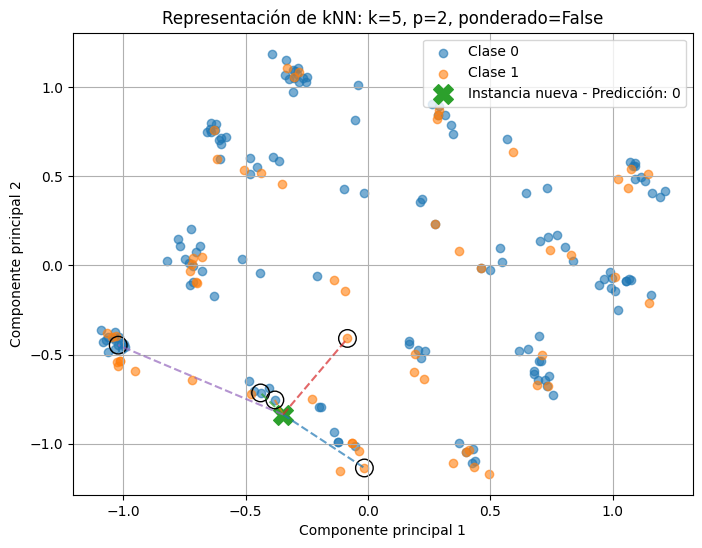

Clase predicha: 0
Vecinos más cercanos:
Índice: 86, Distancia: 1.5000, Clase: 1
Índice: 52, Distancia: 1.7321, Clase: 0
Índice: 66, Distancia: 1.7321, Clase: 0
Índice: 82, Distancia: 1.8028, Clase: 1
Índice: 24, Distancia: 2.0000, Clase: 0


In [ ]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score


# ============================
# 1. Distancia Minkowski
# ============================

def distancia_minkowski(x1, x2, p=2):
    """
    Calcula manualmente la distancia Minkowski entre dos instancias.

    p = 1 -> Manhattan
    p = 2 -> Euclidiana
    p > 2 -> Minkowski general
    """
    suma = 0

    for i in range(len(x1)):
        diferencia = abs(x1[i] - x2[i])
        suma += diferencia ** p

    distancia = suma ** (1 / p)
    return distancia


# ============================
# 2. Voto mayoritario
# ============================

def voto_mayoritario(vecinos, ponderado=False):
    """
    Recibe una lista de vecinos con forma:
    [(distancia, clase), ...]

    Regresa la clase ganadora.
    """
    votos = {}

    for distancia, clase in vecinos:
        if ponderado:
            # Los vecinos más cercanos tienen más peso.
            # El 1e-9 evita división entre cero.
            peso = 1 / (distancia + 1e-9)
        else:
            # Todos los vecinos tienen el mismo peso.
            peso = 1

        if clase not in votos:
            votos[clase] = 0

        votos[clase] += peso

    clase_ganadora = max(votos, key=votos.get)
    return clase_ganadora


# =============================================
# 3. Predicción de una sola instancia con kNN
# =============================================

def predecir_instancia_knn(
    x_nuevo,
    X_entrenamiento,
    y_entrenamiento,
    k=5,
    p=2,
    ponderado=False
):
    """
    Clasifica una sola instancia usando kNN propio.

    Pasos:
    1. Calcula la distancia entre x_nuevo y cada instancia de entrenamiento.
    2. Ordena las distancias de menor a mayor.
    3. Selecciona los k vecinos más cercanos.
    4. Asigna la clase usando voto mayoritario.
    """
    distancias = []

    for i in range(len(X_entrenamiento)):
        d = distancia_minkowski(x_nuevo, X_entrenamiento[i], p=p)
        clase = y_entrenamiento[i]
        distancias.append((d, clase))

    distancias_ordenadas = sorted(distancias, key=lambda elemento: elemento[0])
    vecinos_cercanos = distancias_ordenadas[:k]

    return voto_mayoritario(vecinos_cercanos, ponderado=ponderado)


# ============================================
# 4. Predicción de varias instancias con kNN
# ============================================

def predecir_knn(
    X_nuevo,
    X_entrenamiento,
    y_entrenamiento,
    k=5,
    p=2,
    ponderado=False
):
    """
    Clasifica todas las instancias de X_nuevo usando kNN propio.
    """
    X_entrenamiento_lista = X_entrenamiento.values.tolist()
    y_entrenamiento_lista = y_entrenamiento.values.tolist()
    X_nuevo_lista = X_nuevo.values.tolist()

    predicciones = []

    for x in X_nuevo_lista:
        pred = predecir_instancia_knn(
            x,
            X_entrenamiento_lista,
            y_entrenamiento_lista,
            k=k,
            p=p,
            ponderado=ponderado
        )

        predicciones.append(pred)

    return predicciones


# ===============================
# 5. Gráfica ilustrativa de kNN
# ===============================

def graficar_knn(
    x_nuevo,
    X_entrenamiento,
    y_entrenamiento,
    k=5,
    p=2,
    ponderado=False
):
    """
    Grafica una representación 2D de kNN.

    Nota:
    - La clasificación se calcula usando todas las variables originales.
    - PCA solo se usa para visualizar los datos en dos dimensiones.
    """

    # Convertir datos a listas
    X_entrenamiento_lista = X_entrenamiento.values.tolist()
    y_entrenamiento_lista = y_entrenamiento.values.tolist()

    # Calcular distancias reales usando todas las variables
    distancias = []

    for i in range(len(X_entrenamiento_lista)):
        d = distancia_minkowski(x_nuevo, X_entrenamiento_lista[i], p=p)
        clase = y_entrenamiento_lista[i]
        distancias.append((d, clase, i))

    # Ordenar de menor a mayor distancia
    distancias_ordenadas = sorted(distancias, key=lambda elemento: elemento[0])

    # Tomar los k vecinos más cercanos
    vecinos_cercanos = distancias_ordenadas[:k]

    # Obtener predicción
    vecinos_para_voto = [
        (distancia, clase)
        for distancia, clase, indice in vecinos_cercanos
    ]

    clase_predicha = voto_mayoritario(
        vecinos_para_voto,
        ponderado=ponderado
    )

    # Preparar datos para PCA
    datos_para_pca = X_entrenamiento_lista + [x_nuevo]

    pca = PCA(n_components=2)
    datos_2d = pca.fit_transform(datos_para_pca)

    X_2d = datos_2d[:-1]
    x_nuevo_2d = datos_2d[-1]

    # Crear gráfica
    plt.figure(figsize=(8, 6))

    clases_unicas = sorted(set(y_entrenamiento_lista))

    # Graficar puntos de entrenamiento por clase
    for clase in clases_unicas:
        indices = [
            i
            for i, valor in enumerate(y_entrenamiento_lista)
            if valor == clase
        ]

        plt.scatter(
            X_2d[indices, 0],
            X_2d[indices, 1],
            label=f'Clase {clase}',
            alpha=0.6
        )

    # Graficar instancia nueva
    plt.scatter(
        x_nuevo_2d[0],
        x_nuevo_2d[1],
        marker='X',
        s=200,
        label=f'Instancia nueva - Predicción: {clase_predicha}'
    )

    # Marcar vecinos cercanos y unirlos con líneas punteadas
    for distancia, clase, indice in vecinos_cercanos:
        vecino_2d = X_2d[indice]

        plt.scatter(
            vecino_2d[0],
            vecino_2d[1],
            s=160,
            facecolors='none',
            edgecolors='black'
        )

        plt.plot(
            [x_nuevo_2d[0], vecino_2d[0]],
            [x_nuevo_2d[1], vecino_2d[1]],
            linestyle='--',
            alpha=0.7
        )

    plt.title(f'Representación de kNN: k={k}, p={p}, ponderado={ponderado}')
    plt.xlabel('Componente principal 1')
    plt.ylabel('Componente principal 2')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f'Clase predicha: {clase_predicha}')
    print('Vecinos más cercanos:')

    for distancia, clase, indice in vecinos_cercanos:
        print(f'Índice: {indice}, Distancia: {distancia:.4f}, Clase: {clase}')


# ====================
# 6. Ejemplo de uso
# ====================

# Predicción con kNN propio
y_pred_train_knn = predecir_knn(
    X_train,
    X_train,
    y_train,
    k=5,
    p=2,
    ponderado=False
)

y_pred_test_knn = predecir_knn(
    X_test,
    X_train,
    y_train,
    k=5,
    p=2,
    ponderado=False
)

# Evaluación
acc_train_knn = accuracy_score(y_train, y_pred_train_knn)
acc_test_knn = accuracy_score(y_test, y_pred_test_knn)

print('kNN propio implementado correctamente.')
print('Parámetros: k=5, distancia Minkowski con p=2, ponderado=False')
print(f'Accuracy entrenamiento: {acc_train_knn:.4f}')
print(f'Accuracy evaluación:    {acc_test_knn:.4f}')


# Gráfica ilustrativa de una instancia de evaluación
x_nuevo = X_test.iloc[20].values.tolist()

graficar_knn(
    x_nuevo,
    X_train,
    y_train,
    k=5,
    p=2,
    ponderado=False
)

### 3.2 Árbol de Decisión (scikit-learn)

Decision Tree (depth=4) — Train: 0.7900 | Test: 0.6977


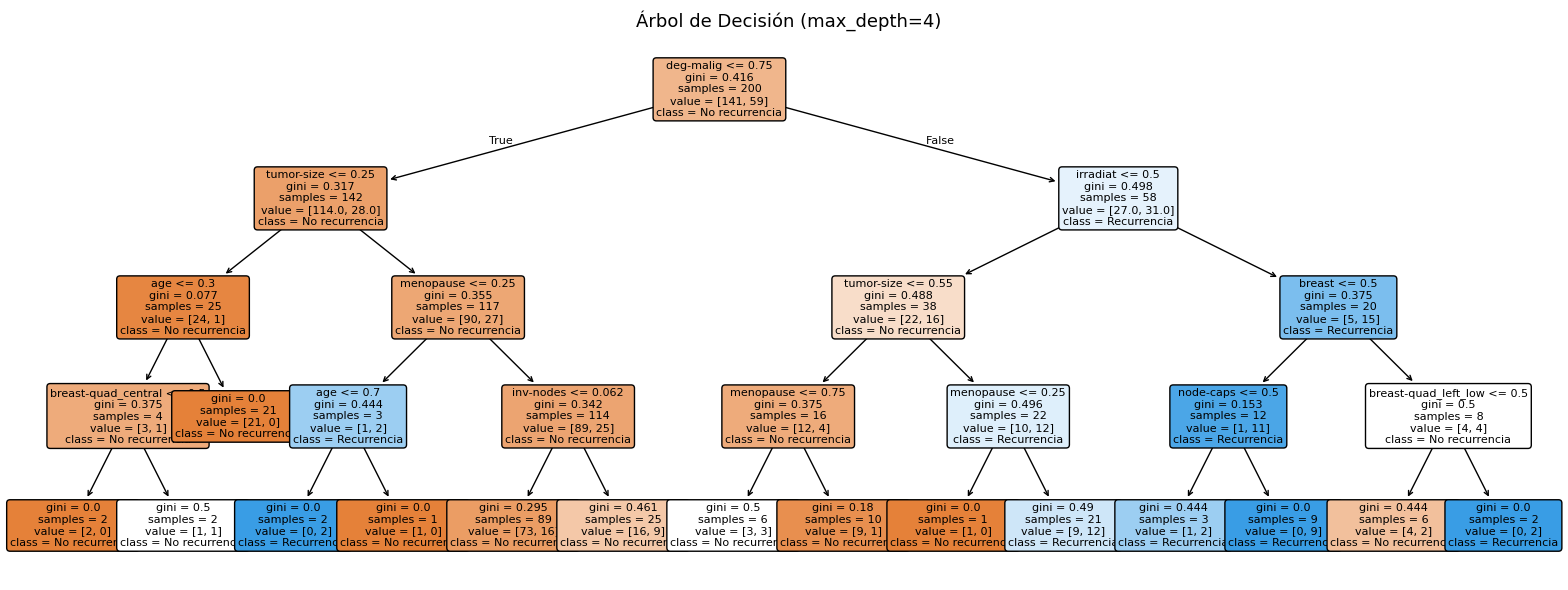

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score

# Modelo base con max_depth=4
dt_base = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
dt_base.fit(X_train, y_train)

acc_train_dt = accuracy_score(y_train, dt_base.predict(X_train))
acc_test_dt  = accuracy_score(y_test,  dt_base.predict(X_test))
print(f'Decision Tree (depth=4) — Train: {acc_train_dt:.4f} | Test: {acc_test_dt:.4f}')

# Visualización del árbol
plt.figure(figsize=(16, 6))
plot_tree(dt_base, feature_names=X.columns.tolist(),
          class_names=['No recurrencia', 'Recurrencia'],
          filled=True, rounded=True, fontsize=8)
plt.title('Árbol de Decisión (max_depth=4)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Random Forest (scikit-learn)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Modelo base
rf_base = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_base.fit(X_train, y_train)

acc_train_rf = accuracy_score(y_train, rf_base.predict(X_train))
acc_test_rf  = accuracy_score(y_test,  rf_base.predict(X_test))
print(f'Random Forest (100 árboles, depth=5) — Train: {acc_train_rf:.4f} | Test: {acc_test_rf:.4f}')

# Importancia de características
importancias = pd.Series(rf_base.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
importancias.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importancia de características — Random Forest', fontsize=12)
plt.ylabel('Importancia (Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## IV. Experimentación y Evaluación

Para cada algoritmo se realizan **8 experimentos** variando sus parámetros principales.  
Se grafican las exactitudes de entrenamiento y evaluación para identificar overfitting y underfitting.

### 4.1 Experimentos kNN

### 4.2 Experimentos Árbol de Decisión

In [ ]:
experimentos_dt = [
    {'max_depth': 1,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 2,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 3,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 6,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': None, 'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'entropy', 'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'gini',    'min_samples_leaf': 5},
]

resultados_dt = []
for i, params in enumerate(experimentos_dt):
    modelo = DecisionTreeClassifier(**params, random_state=42)
    modelo.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test,  modelo.predict(X_test))
    resultados_dt.append({'exp': i+1, 'params': str(params), 'train': acc_tr, 'test': acc_te})
    print(f"Exp {i+1:2d} | {str(params):60s} | Train: {acc_tr:.4f} | Test: {acc_te:.4f}")

df_dt = pd.DataFrame(resultados_dt)

NameError: name 'DecisionTreeClassifier' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
x = df_dt['exp']
ax.plot(x, df_dt['train'], 'o-', color='#4CAF50', label='Entrenamiento', linewidth=2)
ax.plot(x, df_dt['test'],  's--', color='#FF5722', label='Evaluación', linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels([f'Exp {i}' for i in x], rotation=30, ha='right')
ax.set_ylabel('Exactitud')
ax.set_title('Árbol de Decisión — Exactitud por experimento', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Análisis:
- Exp 1 (depth=1): exactitud baja en ambos conjuntos → UNDERFITTING (modelo demasiado simple).
- Exp 6 (sin límite de profundidad): exactitud perfecta en entrenamiento pero baja en test → OVERFITTING.
- Profundidades 3–4 representan el mejor balance; entropia vs gini tienen resultados similares.
- Aumentar min_samples_leaf (Exp 8) actúa como regularización y reduce overfitting.
""")

### 4.3 Experimentos Random Forest

In [ ]:
experimentos_rf = [
    {'n_estimators': 10,  'max_depth': 3,    'max_features': 'sqrt'},
    {'n_estimators': 50,  'max_depth': 3,    'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 3,    'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': 'log2'},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': None},
    {'n_estimators': 200, 'max_depth': 5,    'max_features': 'sqrt'},
]

resultados_rf = []
for i, params in enumerate(experimentos_rf):
    modelo = RandomForestClassifier(**params, random_state=42)
    modelo.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test,  modelo.predict(X_test))
    resultados_rf.append({'exp': i+1, 'params': str(params), 'train': acc_tr, 'test': acc_te})
    print(f"Exp {i+1:2d} | {str(params):65s} | Train: {acc_tr:.4f} | Test: {acc_te:.4f}")

df_rf = pd.DataFrame(resultados_rf)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
x = df_rf['exp']
ax.plot(x, df_rf['train'], 'o-', color='#9C27B0', label='Entrenamiento', linewidth=2)
ax.plot(x, df_rf['test'],  's--', color='#FF9800', label='Evaluación', linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels([f'Exp {i}' for i in x], rotation=30, ha='right')
ax.set_ylabel('Exactitud')
ax.set_title('Random Forest — Exactitud por experimento', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Análisis:
- Más árboles (Exp 1→3) estabilizan la exactitud de evaluación, reduciendo varianza.
- Exp 5 (sin límite de profundidad): overfitting en entrenamiento; el bagging lo mitiga parcialmente
  pero la brecha train-test sigue siendo notable.
- max_features=None (Exp 7) permite que cada árbol vea todos los atributos,
  aumentando correlación entre árboles y reduciendo el beneficio del ensamble.
- Exp 4 y 8 ofrecen el mejor balance con depth=5 y sqrt features.
""")

### 4.4 Comparación final de los tres algoritmos

---
## V. Conclusiones

### ¿Qué algoritmo tuvo mejor desempeño?


### ¿Hay diferencia significativa entre los tres algoritmos?


### Sobreentrenamiento y subentrenamiento


### ¿Los resultados permiten usar estos modelos en el dominio?


### Reflexión sobre la actividad
